In [1]:
!pip install scikit-fem

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np

import skfem as fem
from skfem.models.poisson import laplace
from skfem import MeshTri, ElementTriP1, Basis, asm, BilinearForm, LinearForm
from skfem.utils import condense


Triangulate the cross-section using 3 refinement steps.

<Axes: >

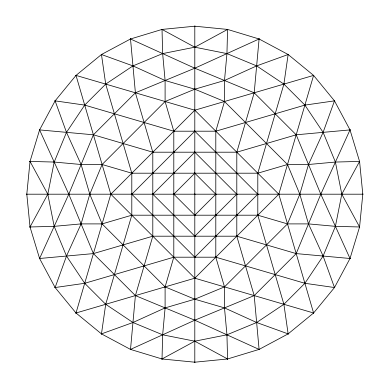

In [3]:
m = MeshTri.init_circle(nrefs=3)
m.draw()

Use triangular elements with piecewise linear basis functions.

In [4]:
e = ElementTriP1()
basis = Basis(m, e)

Define source term: $f = - (1/\mu) dp/dz$

In [5]:
mu = 1.0
dpdz = -1.0  # pressure drop per unit length
f_val = -dpdz / mu

@LinearForm
def rhs(v, w):
    return f_val * v

Create Global Matrices

In [6]:
K = asm(laplace, basis)      # stiffness matrix
F = asm(rhs, basis)          # load vector

Apply Dirichlet boundary conditions: w = 0 ( no-slip )

In [7]:
D = basis.get_dofs()         # interior DOFs
AII, bi, xI, I = condense(K, F, D=D)

In [8]:
w = fem.solve(AII, bi, xI, I)

<Axes: >

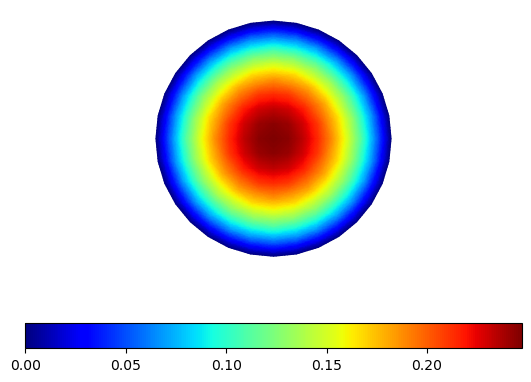

In [9]:
from skfem.visuals.matplotlib import plot

plot(basis, w, shading='gouraud', colorbar={'orientation': 'horizontal'}, nrefs=3)

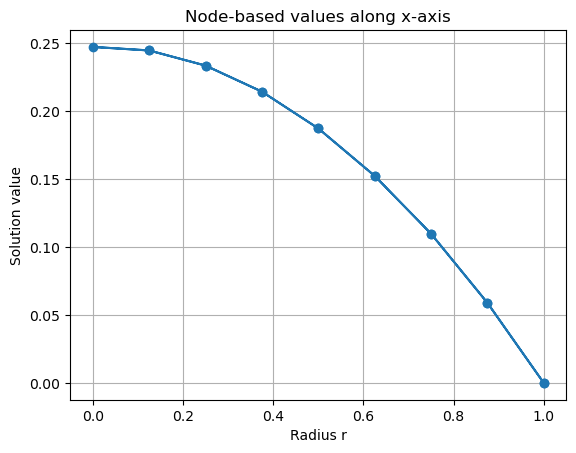

In [10]:
import matplotlib.pyplot as plt

tol = 1e-12

# Node coordinates
X = m.p[0]
Y = m.p[1]

# 1) Select nodes on the x-axis (y ≈ 0)
mask = np.abs(Y) < tol
nodes_on_x = np.where(mask)[0]

# 2) Sort them by x-coordinate
order = np.argsort(X[nodes_on_x])
nodes_sorted = nodes_on_x[order]

# 3) Extract the DOFs for these nodes
# (only works if DOFs correspond to nodes, e.g. P1 scalar)
vals = w[nodes_sorted]

# 4) Radius = |x|
r = np.abs(X[nodes_sorted])

# 5) Plot
plt.plot(r, vals, '-o')
plt.xlabel("Radius r")
plt.ylabel("Solution value")
plt.title("Node-based values along x-axis")
plt.grid(True)
plt.show()


In [11]:
w_max = w.max()
print("Max velocity:", w_max)

Max velocity: 0.24700676799833515
